In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from datetime import datetime

print("Cell executed at:", datetime.now())
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

'''import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session'''

Cell executed at: 2026-05-14 08:09:17.010379


'import os\nfor dirname, _, filenames in os.walk(\'/kaggle/input\'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n\n# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" \n# You can also write temporary files to /kaggle/temp/, but they won\'t be saved outside of the current session'

In [3]:
#This block defines file paths for the CAFA-5 dataset so I can load the data later without repeatedly typing long strings.

from datetime import datetime
BASE = "/kaggle/input/competitions/cafa-5-protein-function-prediction"

FASTA_PATH = f"{BASE}/Train/train_sequences.fasta"
TERMS_PATH = f"{BASE}/Train/train_terms.tsv"
TAXON_PATH = f"{BASE}/Train/train_taxonomy.tsv"
TEST_PATH  = f"{BASE}/Test (Targets)/testsuperset.fasta"
print("Cell executed at:", datetime.now())

Cell executed at: 2026-05-14 08:10:18.263185


In [4]:
!pip install biopython -q
print("Cell executed at:", datetime.now())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.6 MB/s eta 0:00:00a 0:00:01
Cell executed at: 2026-05-14 08:10:40.826048


In [5]:
from Bio import SeqIO
import pandas as pd

# load sequences
def load_fasta(path):
    records = []
    for rec in SeqIO.parse(path, "fasta"):
        records.append({
            "protein_id": rec.id,
            "sequence":   str(rec.seq),
            "seq_len":    len(rec.seq)
        })
    return pd.DataFrame(records)

df_seqs  = load_fasta(FASTA_PATH)
print("Cell executed at:", datetime.now())

Cell executed at: 2026-05-14 08:10:42.678049


In [8]:
df_terms = pd.read_csv(
    TERMS_PATH, 
    sep="\t",
    names=["protein_id", "go_id", "ontology"])
print("Cell executed at:", datetime.now())
print(df_terms)

Cell executed at: 2026-05-14 08:12:43.630060
         protein_id       go_id ontology
0           EntryID        term   aspect
1        A0A009IHW8  GO:0008152      BPO
2        A0A009IHW8  GO:0034655      BPO
3        A0A009IHW8  GO:0072523      BPO
4        A0A009IHW8  GO:0044270      BPO
...             ...         ...      ...
5363859      X5L565  GO:0050649      MFO
5363860      X5L565  GO:0016491      MFO
5363861      X5M5N0  GO:0005515      MFO
5363862      X5M5N0  GO:0005488      MFO
5363863      X5M5N0  GO:0003674      MFO

[5363864 rows x 3 columns]


In [20]:

print("Sequences:", df_seqs.shape)
print("Labels:   ", df_terms.shape)
print()
print(df_seqs.head(3))
print()
print(df_terms.head(3))
print("Cell executed at:", datetime.now())

Sequences: (142246, 3)
Labels:    (5363864, 3)

  protein_id                                           sequence  seq_len
0     P20536  MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...      218
1     O73864  MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...      354
2     O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...      258

   protein_id       go_id ontology
0     EntryID        term   aspect
1  A0A009IHW8  GO:0008152      BPO
2  A0A009IHW8  GO:0034655      BPO
Cell executed at: 2026-05-14 08:15:37.990709


In [21]:
# drop the false header row that snuck in as data
df_terms = df_terms[df_terms["protein_id"] != "EntryID"].reset_index(drop=True)

print("Labels after fix:", df_terms.shape)
print(df_terms.head(3))
print()
print("Ontology counts:")
print(df_terms["ontology"].value_counts())
print("Cell executed at:", datetime.now())

Labels after fix: (5363863, 3)
   protein_id       go_id ontology
0  A0A009IHW8  GO:0008152      BPO
1  A0A009IHW8  GO:0034655      BPO
2  A0A009IHW8  GO:0072523      BPO

Ontology counts:
ontology
BPO    3497732
CCO    1196017
MFO     670114
Name: count, dtype: int64
Cell executed at: 2026-05-14 08:15:50.516358


In [22]:
# labels per protein
labels_per_protein = df_terms.groupby("protein_id")["go_id"].count()
print("Labels per protein:")
print(labels_per_protein.describe().round(1))
print("Cell executed at:", datetime.now())

Labels per protein:
count    142246.0
mean         37.7
std          42.5
min           2.0
25%          10.0
50%          24.0
75%          50.0
max         815.0
Name: go_id, dtype: float64
Cell executed at: 2026-05-14 08:15:54.638668


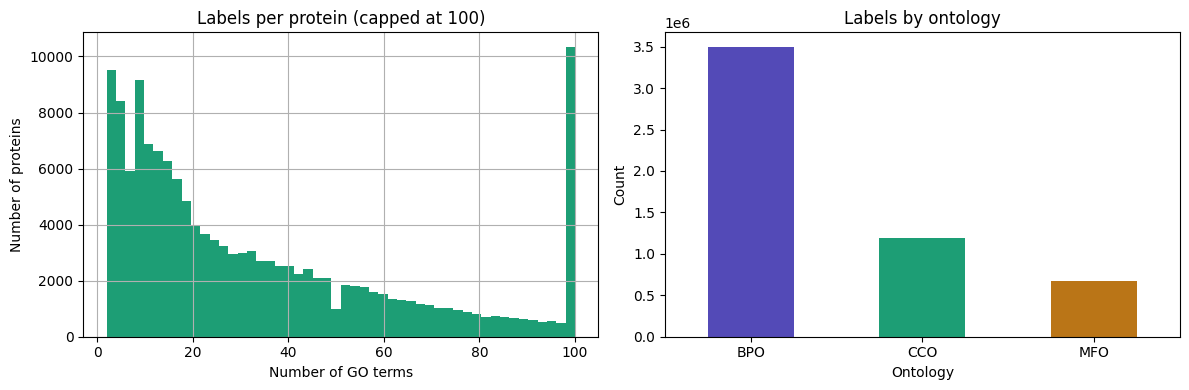

In [23]:
import matplotlib.pyplot as plt
# plot distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels_per_protein.clip(upper=100).hist(bins=50, ax=axes[0], color="#1D9E75")
axes[0].set_title("Labels per protein (capped at 100)")
axes[0].set_xlabel("Number of GO terms")
axes[0].set_ylabel("Number of proteins")

df_terms["ontology"].value_counts().plot(kind="bar", ax=axes[1], color=["#534AB7","#1D9E75","#BA7517"])
axes[1].set_title("Labels by ontology")
axes[1].set_xlabel("Ontology")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [11]:
# merge sequences + labels
labels_grouped = (df_terms.groupby("protein_id")["go_id"]
                           .apply(list)
                           .reset_index()
                           .rename(columns={"go_id": "go_terms"}))

df_train = df_seqs.merge(labels_grouped, on="protein_id", how="inner")
print("Training set shape:", df_train.shape)
print(df_train.head(2))
print("Cell executed at:", datetime.now())

Training set shape: (142246, 4)
  protein_id                                           sequence  seq_len  \
0     P20536  MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...      218   
1     O73864  MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...      354   

                                            go_terms  
0  [GO:0008152, GO:0071897, GO:0044249, GO:000625...  
1  [GO:0061371, GO:0048589, GO:0051641, GO:004885...  
Cell executed at: 2026-05-14 08:14:46.090902


In [12]:
# keep only top 1000 most frequent GO terms
# (the rest appear too rarely to learn from in a baseline)
TOP_N = 1000
top_terms = df_terms["go_id"].value_counts().head(TOP_N).index.tolist()
print(f"Keeping {len(top_terms)} GO terms")
print(f"These cover {df_terms['go_id'].isin(top_terms).mean()*100:.1f}% of all label rows")
print("Cell executed at:", datetime.now())

Keeping 1000 GO terms
These cover 77.3% of all label rows
Cell executed at: 2026-05-14 08:14:48.556883


In [13]:
labels_grouped = (df_terms[df_terms["go_id"].isin(top_terms)]
                           .groupby("protein_id")["go_id"]
                           .apply(list)
                           .reset_index()
                           .rename(columns={"go_id": "go_terms"}))

df_train = df_seqs.merge(labels_grouped, on="protein_id", how="inner")
print("df_train shape:", df_train.shape)
print(df_train.head(2))
print("Cell executed at:", datetime.now())

df_train shape: (142246, 4)
  protein_id                                           sequence  seq_len  \
0     P20536  MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...      218   
1     O73864  MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...      354   

                                            go_terms  
0  [GO:0008152, GO:0044249, GO:0006259, GO:000905...  
1  [GO:0048589, GO:0051641, GO:0048856, GO:000996...  
Cell executed at: 2026-05-14 08:14:56.318444


In [24]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer(classes=top_terms)
Y = mlb.fit_transform(df_train["go_terms"])

print("Y shape:", Y.shape)
print("Label density:", round(Y.mean(), 4))
print("Cell executed at:", datetime.now())

Y shape: (142246, 1000)
Label density: 0.0291
Cell executed at: 2026-05-14 08:16:20.615266


In [15]:
print("Proteins in df_train:", len(df_train))
print("GO terms in Y:", Y.shape[1])
print("Total 1s in Y:", Y.sum())
print("Avg labels per protein:", round(Y.sum(axis=1).mean(), 1))
print("Cell executed at:", datetime.now())

Proteins in df_train: 142246
GO terms in Y: 1000
Total 1s in Y: 4145527
Avg labels per protein: 29.1
Cell executed at: 2026-05-14 08:15:04.280440


In [16]:
import os

BASE = "/kaggle/input/datasets/keerthik22/cafa-5-embedded-files-output-ver-sion-8"

EMB_DIR = f"{BASE}/esm_batches"
print("Cell executed at:", datetime.now())

Cell executed at: 2026-05-14 08:15:08.627454


In [17]:
import glob
import numpy as np

files = sorted(glob.glob(f"{EMB_DIR}/*.npy"))

print("num files:", len(files))

X_esm = np.vstack([np.load(f) for f in files])

print("shape:", X_esm.shape)
print("Cell executed at:", datetime.now())

num files: 2223
shape: (142246, 1280)
Cell executed at: 2026-05-14 08:15:30.501340


In [19]:
print(Y.shape)
print(Y.sum(axis=0)[:10])  # label frequency check
print("Cell executed at:", datetime.now())

(142246, 1000)
[92912 92210 91286 78637 70785 61293 60883 58315 57380 55452]
Cell executed at: 2026-05-14 08:15:30.732338


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X_esm, Y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (113796, 1280)
Test: (28450, 1280)


In [26]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.cuda.memory_allocated()/1e9, "GB used")
print(torch.cuda.memory_reserved()/1e9, "GB reserved")
print(torch.cuda.get_device_properties(0).total_memory/1e9, "GB total")
print("Cell executed at:", datetime.now())

True
Tesla T4
0.0 GB used
0.0 GB reserved
15.637086208 GB total
Cell executed at: 2026-05-14 08:16:53.884896


In [27]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Cell executed at:", datetime.now())

Device: cuda
Cell executed at: 2026-05-14 08:17:00.223120


In [28]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
print("Cell executed at:", datetime.now())

cuda
Cell executed at: 2026-05-14 08:17:31.149009


In [29]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_t = torch.tensor(Y_test, dtype=torch.float32).to(device)
print("Cell executed at:", datetime.now())

Cell executed at: 2026-05-14 08:17:37.802647


In [30]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1280, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 1000)
        )
    
    def forward(self, x):
        return self.network(x)

In [31]:
model = MLP().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
print("Model ready")
print("Cell executed at:", datetime.now())

Model ready
Cell executed at: 2026-05-14 08:19:06.567910


In [ ]:
epochs = 250
batch_size = 256

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for i in range(0, len(X_train_t), batch_size):
        X_batch = X_train_t[i:i+batch_size]
        Y_batch = Y_train_t[i:i+batch_size]
        
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, Y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    scheduler.step(total_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

torch.save(model.state_dict(), "/kaggle/working/mlp_model.pth")
print("Model saved")
print("Cell executed at:", datetime.now())

Epoch 1/250 - Loss: 53.7354
Epoch 2/250 - Loss: 46.8242
Epoch 3/250 - Loss: 46.7266
Epoch 4/250 - Loss: 46.6176
Epoch 5/250 - Loss: 46.5484
Epoch 6/250 - Loss: 46.4662
Epoch 7/250 - Loss: 46.3759
Epoch 10/250 - Loss: 46.1610
Epoch 11/250 - Loss: 46.0927
Epoch 12/250 - Loss: 46.0162
Epoch 13/250 - Loss: 45.9062
Epoch 14/250 - Loss: 45.8274
Epoch 15/250 - Loss: 45.7301
Epoch 16/250 - Loss: 45.6391
Epoch 17/250 - Loss: 45.5422
Epoch 18/250 - Loss: 45.4352
Epoch 19/250 - Loss: 45.3331
Epoch 20/250 - Loss: 45.2430
Epoch 21/250 - Loss: 45.1443
Epoch 22/250 - Loss: 45.0522
Epoch 23/250 - Loss: 44.9366
Epoch 24/250 - Loss: 44.8216
Epoch 25/250 - Loss: 44.7246
Epoch 26/250 - Loss: 44.6038
Epoch 27/250 - Loss: 44.5135
Epoch 28/250 - Loss: 44.4069
Epoch 29/250 - Loss: 44.3005
Epoch 30/250 - Loss: 44.1932
Epoch 31/250 - Loss: 44.0717
Epoch 32/250 - Loss: 43.9706
Epoch 33/250 - Loss: 43.8915
Epoch 34/250 - Loss: 43.7924
Epoch 35/250 - Loss: 43.6902
Epoch 36/250 - Loss: 43.5753
Epoch 37/250 - Loss: 

In [ ]:
model.eval()
with torch.no_grad():
    Y_pred = torch.sigmoid(model(X_test_t)).cpu().numpy()

Y_test_np = Y_test_t.cpu().numpy()

def compute_precision_recall_at_threshold(Y_true, Y_pred, threshold=0.5):
    Y_bin = (Y_pred >= threshold).astype(int)
    tp = (Y_bin * Y_true).sum(axis=1)
    pred_pos = Y_bin.sum(axis=1)
    true_pos = Y_true.sum(axis=1)
    precision = np.where(pred_pos > 0, tp / pred_pos, 0).mean()
    recall = np.where(true_pos > 0, tp / true_pos, 0).mean()
    return precision, recall

for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    p, r = compute_precision_recall_at_threshold(Y_test_np, Y_pred, threshold=t)
    print(f"Threshold {t} — Precision: {p:.4f}, Recall: {r:.4f}")
    print("Cell executed at:", datetime.now())

In [ ]:
def compute_fmax(Y_true, Y_pred):
    thresholds = np.arange(0.0, 1.01, 0.01)
    best_f = 0
    best_t = 0
    
    for t in thresholds:
        Y_bin = (Y_pred >= t).astype(int)
        tp = (Y_bin * Y_true).sum(axis=1)
        pred_pos = Y_bin.sum(axis=1)
        true_pos = Y_true.sum(axis=1)
        precision = np.where(pred_pos > 0, tp / pred_pos, 0)
        recall = np.where(true_pos > 0, tp / true_pos, 0)
        f = np.where(precision + recall > 0,
                     2 * precision * recall / (precision + recall), 0)
        fmax = f.mean()
        if fmax > best_f:
            best_f = fmax
            best_t = t
    
    return best_f, best_t




fmax, best_threshold = compute_fmax(Y_test_np, Y_pred)
print(f"Fmax: {fmax:.4f} at threshold {best_threshold:.2f}")
print("Cell executed at:", datetime.now())

---------------parent child------------------

In [ ]:
!pip install goatools -q
print("Cell executed at:", datetime.now())

In [ ]:
from goatools.obo_parser import GODag
godag = GODag('/kaggle/input/competitions/cafa-5-protein-function-prediction/Train/go-basic.obo')
print("Loaded:", len(godag), "GO terms")
print("Cell executed at:", datetime.now())

In [ ]:
go_terms = list(top_terms)

def get_go_depth(go_id):
    if go_id in godag:
        return godag[go_id].depth
    return None

depths = {go_id: get_go_depth(go_id) for go_id in go_terms}

depths_list = [d for d in depths.values() if d is not None]
print("Max depth:", max(depths_list))
print("Min depth:", min(depths_list))
print("Avg depth:", round(sum(depths_list)/len(depths_list), 1))
print("Cell executed at:", datetime.now())

In [ ]:
parent_idx = [
    i for i, g in enumerate(go_terms)
    if depths[g] is not None and depths[g] <= 2
]

child_idx = [
    i for i, g in enumerate(go_terms)
    if depths[g] is not None and depths[g] > 2
]

print("Parent terms (depth ≤ 2):", len(parent_idx))
print("Child terms (depth > 2):", len(child_idx))
print("Cell executed at:", datetime.now())

In [ ]:
print(Y_pred.shape)

In [ ]:
def compute_fmax(Y_true, Y_pred):
    thresholds = np.arange(0.0, 1.01, 0.01)
    best_f = 0
    best_t = 0
    
    for t in thresholds:
        Y_bin = (Y_pred >= t).astype(int)
        tp = (Y_bin * Y_true).sum(axis=1)
        pred_pos = Y_bin.sum(axis=1)
        true_pos = Y_true.sum(axis=1)
        precision = np.where(pred_pos > 0, tp / pred_pos, 0)
        recall = np.where(true_pos > 0, tp / true_pos, 0)
        f = np.where(precision + recall > 0,
                     2 * precision * recall / (precision + recall), 0)
        fmax = f.mean()
        if fmax > best_f:
            best_f = fmax
            best_t = t
    
    return best_f, best_t

fmax_parent, t_parent = compute_fmax(Y_test_np[:, parent_idx], Y_pred[:, parent_idx])
fmax_child, t_child = compute_fmax(Y_test_np[:, child_idx], Y_pred[:, child_idx])

print(f"Parent GO terms Fmax: {fmax_parent:.4f} at threshold {t_parent:.2f}")
print(f"Child GO terms  Fmax: {fmax_child:.4f} at threshold {t_child:.2f}")

In [ ]:
def compute_fmax_split_parent_child(Y_true, Y_pred, label=""):
    thresholds = np.arange(0.0, 1.01, 0.01)
    best_f = 0
    best_t = 0
    
    for t in thresholds:
        Y_bin = (Y_pred >= t).astype(int)
        tp = (Y_bin * Y_true).sum(axis=1)
        pred_pos = Y_bin.sum(axis=1)
        true_pos = Y_true.sum(axis=1)
        precision = np.where(pred_pos > 0, tp / pred_pos, 0)
        recall = np.where(true_pos > 0, tp / true_pos, 0)
        f = np.where(precision + recall > 0,
                     2 * precision * recall / (precision + recall), 0)
        fmax = f.mean()
        if fmax > best_f:
            best_f = fmax
            best_t = t
    
    return best_f, best_t

fmax_parent, t_parent = compute_fmax_split_parent_child(Y_test_np[:, parent_idx], Y_pred[:, parent_idx], "Parent")
fmax_child, t_child = compute_fmax_split_parent_child(Y_test_np[:, child_idx], Y_pred[:, child_idx], "Child")

print(f"Parent GO terms Fmax: {fmax_parent:.4f} at threshold {t_parent:.2f}")
print(f"Child GO terms  Fmax: {fmax_child:.4f} at threshold {t_child:.2f}")

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# per-depth threshold predictions
Y_pred_adjusted = Y_pred.copy()

# apply lower threshold for child terms by scaling predictions up
# parent terms: keep as is (threshold 0.22)
# child terms: scale up so effective threshold becomes 0.13

Y_pred_binary = np.zeros_like(Y_pred)

# parent terms use threshold 0.22
Y_pred_binary[:, parent_idx] = (Y_pred[:, parent_idx] >= 0.22).astype(int)

# child terms use threshold 0.13
Y_pred_binary[:, child_idx] = (Y_pred[:, child_idx] >= 0.13).astype(int)

# compute Fmax on combined binary predictions
tp = (Y_pred_binary * Y_test_np).sum(axis=1)
pred_pos = Y_pred_binary.sum(axis=1)
true_pos = Y_test_np.sum(axis=1)

precision = np.where(pred_pos > 0, tp / pred_pos, 0)
recall = np.where(true_pos > 0, tp / true_pos, 0)
f1 = np.where(precision + recall > 0,
              2 * precision * recall / (precision + recall), 0)

print(f"Per-depth threshold Fmax: {f1.mean():.4f}")
print(f"Precision: {precision.mean():.4f}")
print(f"Recall: {recall.mean():.4f}")

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# find best threshold per GO term
per_term_thresholds = np.zeros(1000)

for j in range(1000):
    best_f = 0
    best_t = 0.5
    
    for t in np.arange(0.05, 0.95, 0.05):
        y_true_j = Y_test_np[:, j]
        y_pred_j = (Y_pred[:, j] >= t).astype(int)
        
        tp = (y_pred_j * y_true_j).sum()
        pred_pos = y_pred_j.sum()
        true_pos = y_true_j.sum()
        
        p = tp / pred_pos if pred_pos > 0 else 0
        r = tp / true_pos if true_pos > 0 else 0
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0
        
        if f > best_f:
            best_f = f
            best_t = t
    
    per_term_thresholds[j] = best_t

print("Threshold distribution:")
print(f"Min: {per_term_thresholds.min():.2f}")
print(f"Max: {per_term_thresholds.max():.2f}")
print(f"Avg: {per_term_thresholds.mean():.2f}")

In [ ]:
# apply per-term thresholds
Y_pred_per_term = np.zeros_like(Y_pred)

for j in range(1000):
    Y_pred_per_term[:, j] = (Y_pred[:, j] >= per_term_thresholds[j]).astype(int)

# compute Fmax
tp = (Y_pred_per_term * Y_test_np).sum(axis=1)
pred_pos = Y_pred_per_term.sum(axis=1)
true_pos = Y_test_np.sum(axis=1)

precision = np.where(pred_pos > 0, tp / pred_pos, 0)
recall = np.where(true_pos > 0, tp / true_pos, 0)
f1 = np.where(precision + recall > 0,
              2 * precision * recall / (precision + recall), 0)

print(f"Per-term threshold Fmax: {f1.mean():.4f}")
print(f"Precision: {precision.mean():.4f}")
print(f"Recall: {recall.mean():.4f}")

In [ ]:
# pick a protein
sample_protein = df_train.iloc[0]['protein_id']
sample_terms = df_train.iloc[0]['go_terms']
print("Protein:", sample_protein)
print("GO terms:", sample_terms[:5])

In [ ]:
# check parents of first GO term
go_id = 'GO:0008152'
if go_id in godag:
    parents = godag[go_id].parents
    print(f"Parents of {go_id}:")
    for p in parents:
        print(f"  {p.item_id} — in protein's terms: {p.item_id in sample_terms}")

In [ ]:
missing_parents = 0
total_checked = 0

for _, row in df_train.iterrows():
    terms = set(row['go_terms'])
    for go_id in list(terms):
        if go_id in godag:
            for parent in godag[go_id].parents:
                if parent.item_id in top_terms:  # only check if parent is in our top 1000
                    total_checked += 1
                    if parent.item_id not in terms:
                        missing_parents += 1

print(f"Missing parent annotations: {missing_parents} / {total_checked}")
print(f"Missing rate: {missing_parents/total_checked*100:.1f}%")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
print("Cell started at:", datetime.now())
clf_esm = MultiOutputClassifier(
    LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42, verbose=1),
    n_jobs=-1
)

clf_esm.fit(X_train, Y_train)
print("Training done.")
print("Cell executed at:", datetime.now())

In [ ]:
import joblib
joblib.dump(clf_esm, "/kaggle/working/lr_esm_model.pkl")
print("Model saved")
print("Model saved")

In [ ]:
joblib.dump(clf_esm, "/kaggle/working/lr_esm_model.pkl")
print("Saved")

In [ ]:
import os
import shutil

os.makedirs("/kaggle/output", exist_ok=True)

shutil.copy("/kaggle/working/lr_esm_model.pkl", "/kaggle/output/lr_esm_model.pkl")

print("Copied to output")

In [ ]:
import pickle

with open("/kaggle/output/lr_esm_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully")

In [ ]:
import os
print(os.path.getsize("/kaggle/output/lr_esm_model.pkl"))

In [ ]:
from joblib import load

model = load("/kaggle/output/lr_esm_model.pkl")
print("Loaded successfully")

In [ ]:
joblib.dump(clf_esm, "/kaggle/output/lr_esm_model.pkl")

print("Saved to output")

In [ ]:
print("Cell started at:", datetime.now())
Y_pred_lr_esm = np.column_stack([clf_esm.estimators_[i].predict_proba(X_test)[:, 1] for i in range(1000)])
fmax, best_threshold = compute_fmax(Y_test, Y_pred_lr_esm)
print(f"LR on ESM Fmax: {fmax:.4f} at threshold {best_threshold:.2f}")
print("Cell executed at:", datetime.now())

In [ ]:
consistent = 0
inconsistent = 0

for j, go_id in enumerate(go_terms):
    if go_id not in godag:
        continue
    for parent in godag[go_id].parents:
        if parent.item_id not in top_terms:
            continue
        parent_idx_j = go_terms.index(parent.item_id)
        
        # where model predicts child but not parent
        child_pred = Y_pred[:, j] > 0.2
        parent_pred = Y_pred[:, parent_idx_j] > 0.2
        
        inconsistent += (child_pred & ~parent_pred).sum()
        consistent += (child_pred & parent_pred).sum()

print(f"Consistent predictions: {consistent}")
print(f"Inconsistent predictions: {inconsistent}")
print(f"Inconsistency rate: {inconsistent/(consistent+inconsistent)*100:.1f}%")

Kmer+Esm--------------------------------------------------------------------------

In [19]:

import numpy as np

AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def aa_composition(sequence):
    seq = sequence.upper()
    length = len(seq)
    return [seq.count(aa) / length for aa in AMINO_ACIDS]

X_comp = np.array([aa_composition(seq) for seq in df_train["sequence"]])
print("X_comp shape:", X_comp.shape)  # expect (142246, 20)
print("Cell executed at:", datetime.now())


X_comp shape: (142246, 20)
Cell executed at: 2026-05-11 09:27:59.735491


In [20]:
from itertools import product
import numpy as np

AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")
KMER_VOCAB = ["".join(p) for p in product(AMINO_ACIDS, repeat=2)]
KMER_INDEX = {km: i for i, km in enumerate(KMER_VOCAB)}

def kmer_frequency_fast(sequence, k=2):
    seq = sequence.upper()
    counts = np.zeros(400)
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        idx = KMER_INDEX.get(kmer)
        if idx is not None:
            counts[idx] += 1
    total = counts.sum()
    return counts / total if total > 0 else counts

X_kmer = np.array([kmer_frequency_fast(seq) for seq in df_train["sequence"]])
print("X_kmer shape:", X_kmer.shape)
print("Cell executed at:", datetime.now())

X_kmer shape: (142246, 400)
Cell executed at: 2026-05-11 09:28:40.488874


In [22]:
X = np.hstack([X_comp, X_kmer])
print("X shape:", X.shape)
print("Cell executed at:", datetime.now())

X shape: (142246, 420)
Cell executed at: 2026-05-11 09:28:46.656893


In [23]:
X_combined = np.hstack([X_esm, X])
print("Combined shape:", X_combined.shape)
print("Cell executed at:", datetime.now())

Combined shape: (142246, 1700)
Cell executed at: 2026-05-11 09:28:58.763041


In [24]:
# Step 2 - Train/test split
from sklearn.model_selection import train_test_split
X_train_c, X_test_c, Y_train_c, Y_test_c = train_test_split(
    X_combined, Y, test_size=0.2, random_state=42
)
print("Train:", X_train_c.shape)
print("Test:", X_test_c.shape)
print("Cell executed at:", datetime.now())

Train: (113796, 1700)
Test: (28450, 1700)
Cell executed at: 2026-05-11 09:29:12.284363


In [26]:
# Step 3 - Convert to tensors
X_train_ct = torch.tensor(X_train_c, dtype=torch.float32).to(device)
Y_train_ct = torch.tensor(Y_train_c, dtype=torch.float32).to(device)
X_test_ct = torch.tensor(X_test_c, dtype=torch.float32).to(device)
Y_test_ct = torch.tensor(Y_test_c, dtype=torch.float32).to(device)
print("Tensors ready")
print("Cell executed at:", datetime.now())

NameError: name 'device' is not defined

In [25]:
print(X_combined.shape)  # should be (142246, 1700)
print(X_train_c.shape)   # should be (113796, 1700)
print(Y_train_c.shape)   # should be (113796, 1000)

(142246, 1700)
(113796, 1700)
(113796, 1000)


In [ ]:

# Step 4 - New MLP for 1700 input dims
class MLPCombined(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1700, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 1000)
        )
    
    def forward(self, x):
        return self.network(x)

model_c = MLPCombined().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_c.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
print("Model ready")

In [ ]:
epochs = 250
batch_size = 256

for epoch in range(epochs):
    model_c.train()
    total_loss = 0
    
    for i in range(0, len(X_train_ct), batch_size):
        X_batch = X_train_ct[i:i+batch_size]
        Y_batch = Y_train_ct[i:i+batch_size]
        
        optimizer.zero_grad()
        preds = model_c(X_batch)
        loss = criterion(preds, Y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    scheduler.step(total_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

torch.save(model_c.state_dict(), "/kaggle/working/mlp_combined.pth")
print("Model saved")

In [ ]:
model_c.eval()
with torch.no_grad():
    Y_pred_c = torch.sigmoid(model_c(X_test_ct)).cpu().numpy()

Y_test_np = Y_test_ct.cpu().numpy()
fmax, best_threshold = compute_fmax(Y_test_np, Y_pred_c)
print(f"Fmax: {fmax:.4f} at threshold {best_threshold:.2f}")

In [29]:
!pip install lightgbm -q
from lightgbm import LGBMClassifier
from sklearn.multioutput import MultiOutputClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")
print("Imports done")

Imports done


In [28]:
!pip install lightgbm -q
from lightgbm import LGBMClassifier
from sklearn.multioutput import MultiOutputClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")
print("Imports done")

Imports done


In [ ]:
from datetime import datetime
print("Cell started at:", datetime.now())

lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=1,
    verbose=-1
)

clf_lgb = MultiOutputClassifier(lgb, n_jobs=4)
print("Starting training...")
clf_lgb.fit(X_train_c, Y_train_c)
print("Training done.")

joblib.dump(clf_lgb, "/kaggle/working/lgb_combined_model.pkl")
print("Model saved")
print("Cell finished at:", datetime.now())

Cell started at: 2026-05-11 09:33:46.660955
Starting training...
